# Weighted BFE Implementation

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.table import Table
import cmasher as cmr

from astropy.io import fits
from astroquery.gaia import Gaia
from astropy.table import Table
from astropy import units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
from astropy.coordinates import SkyCoord, Galactocentric

from df_helpers_data import *
import agama

In [3]:
from gaiaunlimited.selectionfunctions import DR3RVSSelectionFunction

In [4]:
hdul = fits.open("Gaia_data_all_v1.fits")
gaia_data = hdul[1].data
hdul.info()
print(gaia_data.columns.names)

mask = (gaia_data['r_med_photogeo'] < 1000)
dr3_data = gaia_data[mask]
print(len(dr3_data))

# del gaia_data
del hdul

Filename: Gaia_data_all_v1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  votable       1 BinTableHDU    104   20339690R x 17C   ['K', 'D', 'D', 'D', 'E', 'D', 'E', 'D', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E']   
['source_id', 'ra', 'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'radial_velocity', 'radial_velocity_error', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'r_med_photogeo', 'r_lo_photogeo', 'r_hi_photogeo']
12549356


### Get selection function for each point

In [ ]:
dr3_icrs = SkyCoord(ra=dr3_data["ra"] * u.degree, dec=dr3_data["dec"] * u.degree, distance=dr3_data["r_med_photogeo"] * u.pc, 
                    pm_ra_cosdec=dr3_data['pmra']*u.mas/u.yr,pm_dec=dr3_data['pmdec']*u.mas/u.yr,radial_velocity=dr3_data['radial_velocity']*u.km/u.s,frame="icrs")
dr3_galcen = dr3_icrs.transform_to(Galactocentric)
dr3_galactic = dr3_icrs.transform_to(coord.Galactic)

In [6]:
rvssf = DR3RVSSelectionFunction()
S = rvssf.query(coords=dr3_galactic, g=dr3_data['phot_g_mean_mag'], c = dr3_data['phot_bp_mean_mag']-dr3_data['phot_rp_mean_mag'])

/Users/Tavangar/Work/virtual_envs/.DR3_snails_env/lib/python3.12/site-packages/gaiaunlimited/selectionfunctions/subsample.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if ds.dims.keys() - set(["ipix"]) == {"g", "c"}:


### Getting Actions and Angles

In [7]:
agama.setUnits(mass=1.0, length=1.0, velocity=1.0)
finder = agama.ActionFinder
# potential = agama.Potential("MWPotentialHunter24_axi.ini")
potential = agama.Potential(
    "/Users/Tavangar/Work/packages/Agama/data/PriceWhelan22.ini")

In [8]:
# Extract Cartesian positions
x_ = dr3_galcen.x.to(u.kpc)
y_ = dr3_galcen.y.to(u.kpc)
z_ = dr3_galcen.z.to(u.kpc)

# Extract velocities
vx_ = dr3_galcen.v_x.to(u.km/u.s)
vy_ = dr3_galcen.v_y.to(u.km/u.s)
vz_ = dr3_galcen.v_z.to(u.km/u.s)

galcen_array = np.column_stack([x_.value,y_.value,z_.value,
                                   vx_.value,vy_.value,vz_.value])

In [9]:
galcen_array

array([[-8.48850871e+00,  2.00745655e-02, -3.96203149e-01,
         1.21779690e+02,  2.02461874e+02, -2.88984476e+01],
       [-8.37627141e+00,  1.43525298e-02, -2.67453268e-01,
         2.01502953e+01,  2.16583460e+02, -1.06792981e+01],
       [-8.30652769e+00,  1.09793603e-02, -1.87053211e-01,
         1.41530745e+01,  1.93065819e+02, -1.29569931e+01],
       ...,
       [-7.88844214e+00,  2.64053890e-01, -1.70966243e-01,
        -2.08945197e+00,  2.42846417e+02,  4.20112842e+00],
       [-7.74756707e+00,  4.26357616e-01, -2.89257554e-01,
         4.23112022e+01,  1.93620973e+02, -8.77175990e+00],
       [-7.71769110e+00,  4.59726374e-01, -3.10833330e-01,
        -2.45583018e+01,  2.17001065e+02, -1.51590170e+01]],
      shape=(12549356, 6))

In [ ]:
af = finder(potential, interp=False)
Disk_actions, Disk_angles, Disk_freqs = af(galcen_array, angles=True)

In [10]:
# Action - Angle calculation
af = finder(potential, interp=False)

# Replace disc phasespace (see above) with what particles you want to calculate for
Disk_actions, Disk_angles, Disk_freq = af(galcen_array, angles=True) #getting the actions, angles, and freqs

Jr_disk = Disk_actions[:, 0] #unpacking them all
Jz_disk = Disk_actions[:, 1]
Jphi_disk = Disk_actions[:, 2]

Theta_r_disk = Disk_angles[:, 0]
Theta_z_disk = Disk_angles[:, 1]
Theta_phi_disk = Disk_angles[:, 2]

Omega_r_disk = Disk_freq[:, 0]
Omega_z_disk = Disk_freq[:, 1]
Omega_phi_disk = Disk_freq[:, 2]

In [14]:
theta_z = np.mod(Theta_z_disk, 2*np.pi)
jz = Jz_disk

## Getting coefficients

In [44]:
def effective_sample_size(weights):
    """
    Kish's effective sample size for weighted samples:
        ESS = (sum w_i)^2 / sum w_i^2.
    For uniform weights ESS = N. For badly-skewed weights ESS << N
    and the estimator is dominated by a few high-weight points.
    """
    s1 = float(np.sum(weights))
    s2 = float(np.sum(np.asarray(weights) ** 2))
    return (s1 * s1 / s2) if s2 > 0 else 0.0


def n_m(m):
    """deltam0 is 0 for all orders except m=0, when it is 1.
    this is the angular normalisation."""
    deltam0 = 0.
    if m==0: deltam0 = 1.
    return np.power( (deltam0+1)*np.pi/2. , -0.5)
    
def disk_lag(n, Jzs, a):
    '''
    Taken from Weinberg and Petersen 2021 and Johnson+22 as good approximation for disk
    Parameters:
    --------------------------------------
    n   : order of the Laguerre polynomial
    Jzs : actions
    a   : scale length of the disk

    Returns:
    --------------------------------------
    Laguerre part of the coefficient evaluation for the BFE
    '''
    norm = 2/(a*np.sqrt(n+1)) #references diverge on whether there is factor of two --> no factor of 2 and a=3 gives the disk exponential density for the 0th order term

    lag = scipy.special.eval_genlaguerre(n,1,2*Jzs/a) #take alpha=1 following prior work

    return norm * np.exp(-Jzs/a) * lag

def get_coeffs(jz, thetaz, weights, m_max, n_max, a):
    '''
    Generate the coefficients for the BFE
    '''
    coeffs = np.zeros((m_max, n_max), dtype=np.complex128)      #(m_max, n_max))
    
    #calculate coefficients
    #print('Calculating coefficients...')
    exp_m = [np.exp(1j * m * thetaz) for m in range(m_max)]
    for m, n in product(range(m_max), range(n_max)):
        coeff = n_m(m) * np.sum(weights * disk_lag(n, jz, a) * exp_m[m] * jz)
        print(coeff)
        coeffs[m, n] = coeff
    return coeffs


In [58]:
S_floor = 0.05                                  # drop very-low-S stars
mask = np.isfinite(jz) & np.isfinite(theta_z) & (S >= S_floor) & np.isfinite(S)
w = np.zeros_like(S)
w[mask] = 1.0 / S[mask]
# w = w / w.sum()                                 # For Hájek normalization, divide by sum of weights to get a proper probability distribution
print("ESS =", effective_sample_size(w[mask]))

ESS = 9002225.14744431


In [54]:
_, a = scipy.stats.expon.fit(jz[~np.isnan(jz)], floc=0)

coeffs_hat = get_coeffs(jz, theta_z, weights=w, m_max=3, n_max=10, a=a)

(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)


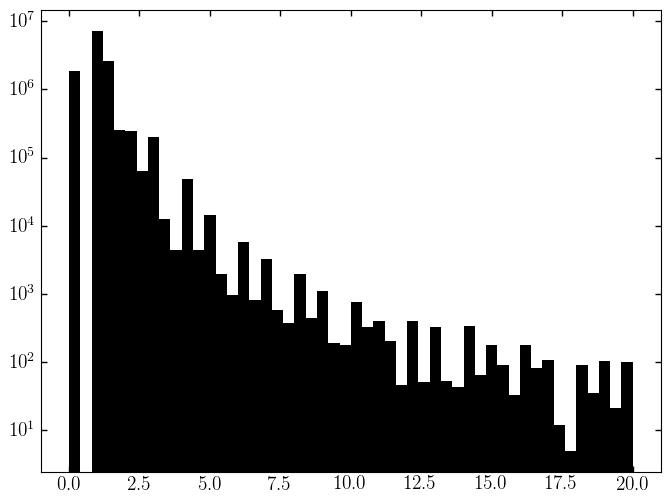

In [59]:
plt.hist(w, bins=50)
plt.yscale('log')
plt.show()